In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

events = pd.read_csv("events_cleaned.csv")

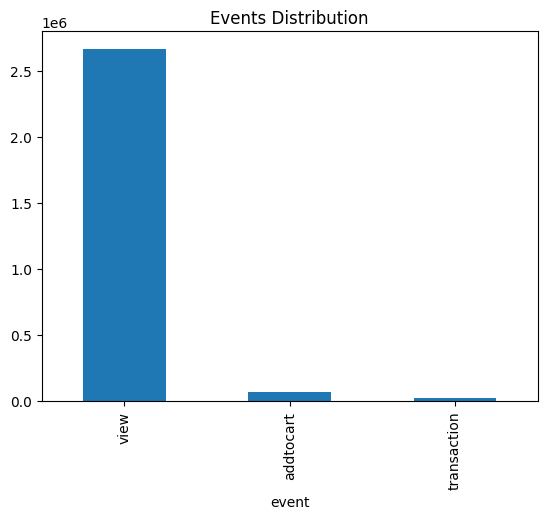

In [2]:
events["event"].value_counts()
events["visitorid"].nunique()
events["itemid"].nunique()

events["event"].value_counts().plot(kind="bar")
plt.title("Events Distribution")
plt.show()

Unique Visitors: 1407580
Unique Items: 235061


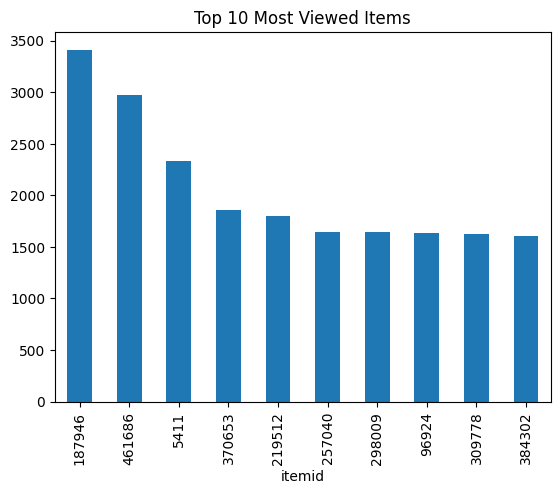

In [3]:
print("Unique Visitors:", events["visitorid"].nunique())
print("Unique Items:", events["itemid"].nunique())

top_items = events["itemid"].value_counts().head(10)
top_items.plot(kind="bar")
plt.title("Top 10 Most Viewed Items")
plt.show()

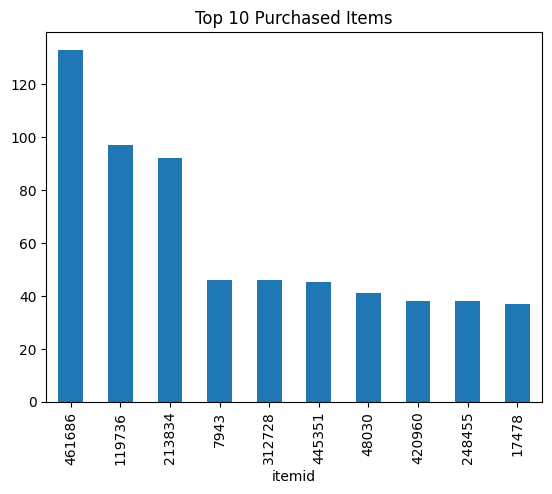

In [4]:
purchased = events[events["event"]== "transaction"] 

top_purchased = purchased["itemid"].value_counts().head(10)

top_purchased.plot(kind ="bar") 
plt.title("Top 10 Purchased Items")
plt.show()

In [5]:
events.groupby("event")["visitorid"].nunique()

event
addtocart        37722
transaction      11719
view           1404179
Name: visitorid, dtype: int64

In [6]:
#conversion Funnel

views = len(events[events["event"] == "view"])
cart = len(events[events["event"] == "addtocart"])
purchases = len(events[events["event"] == "transaction"])

print("Views:", views)
print("Carts:", cart)
print("Purchases:", purchases)

Views: 2664218
Carts: 68966
Purchases: 22457


In [7]:
#conversion rates

cart_rate = (cart / views) * 100
purchase_rate = (purchases / views) * 100

print("Cart Rate:", round(cart_rate , 2), "%")
print("Purchase Rate:", round(purchase_rate , 2), "%")

Cart Rate: 2.59 %
Purchase Rate: 0.84 %


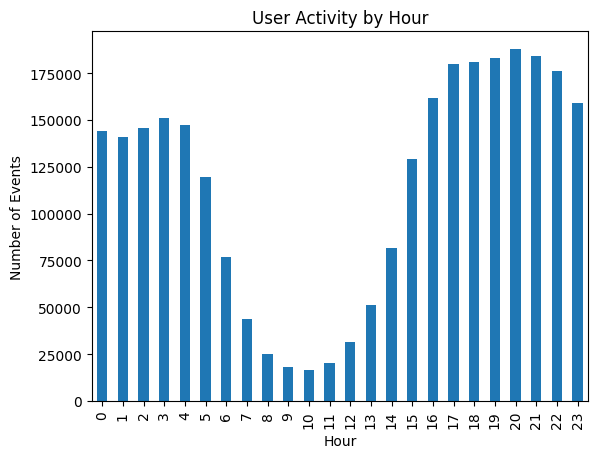

In [11]:
events["timestamp"] = pd.to_datetime(events["timestamp"], unit="ms")

events["hour"] = events["timestamp"].dt.hour

events["hour"].value_counts().sort_index().plot(kind="bar")
plt.title("User Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.show()

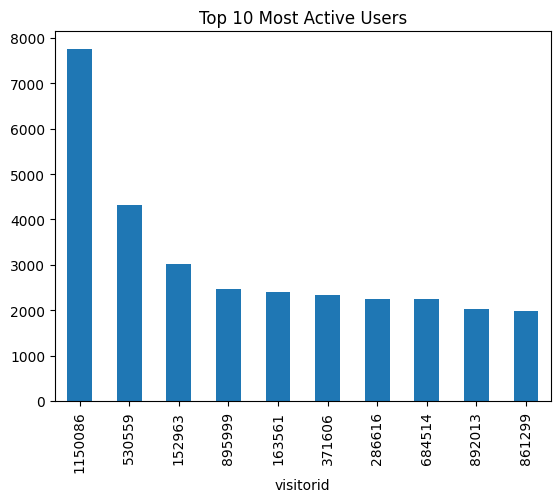

In [9]:
top_users = events["visitorid"].value_counts().head(10)

top_users.plot(kind="bar")
plt.title("Top 10 Most Active Users")
plt.show()

In [13]:
events.groupby("event")["visitorid"].nunique()

event
addtocart        37722
transaction      11719
view           1404179
Name: visitorid, dtype: int64

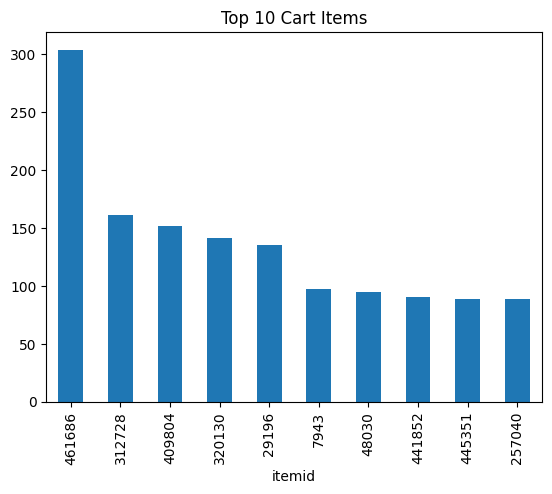

In [15]:
cart = events[events["event"] == "addtocart"]

top_cart = cart["itemid"].value_counts().head(10)

top_cart.plot(kind = "bar")
plt.title("Top 10 Cart Items")
plt.show()

In [16]:
events["event"].value_counts(normalize=True) * 100

event
view           96.682333
addtocart       2.502721
transaction     0.814947
Name: proportion, dtype: float64

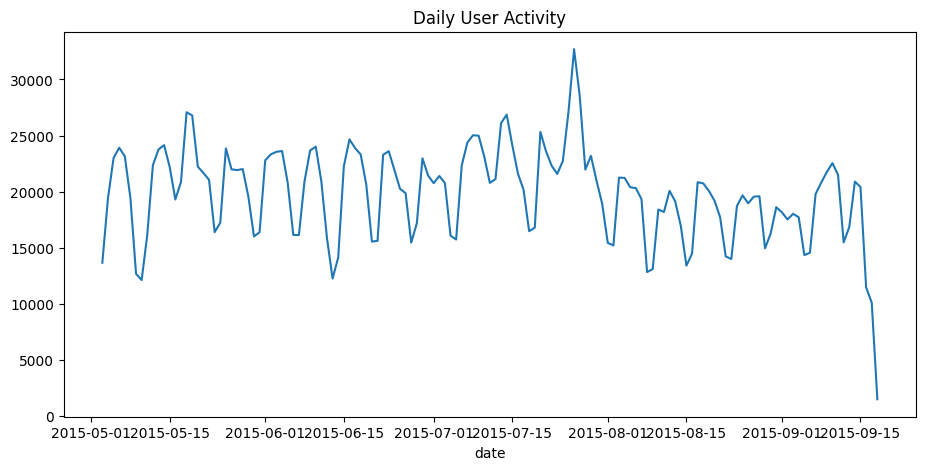

In [19]:
events["date"] = events["timestamp"].dt.date

events.groupby("date").size().plot(figsize=(11,5))
plt.title("Daily User Activity")
plt.show()

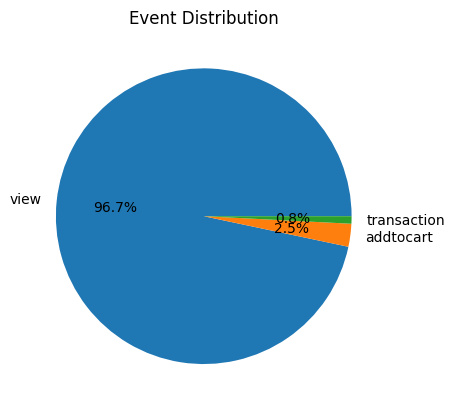

In [21]:
events["event"].value_counts().plot(kind = "pie",autopct = "%1.1f%%")
plt.title("Event Distribution")
plt.ylabel("")
plt.show()